In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan
import pandas as pd
import yaml

sys.path.append("/glade/u/home/islas/python/CESM2_with_CMIP7_aer/utils/")
from convert_units import *
from reading_utils import *
from molecular_weights_diameters_densities import *
from dask_utils import *

from CASutils import calendar_utils as cal

### Species to plot

In [15]:
species_to_plot = ['SO2','so4_a1_ship','so4_a1_ag_slv_was',
                   'so4_a2','bc_a4','pom_a4','SOAG',
                   'so4_a1_ene_ind','SO2','so4_a1_bmb','bc_a4',
                   'pom_a4','SOAG']
emiss_type_to_plot = ['sfc','sfc','sfc',
                      'sfc','sfc','sfc','sfc',
                      'elev','sfc','sfc','sfc',
                      'sfc','sfc']
forcing_type_to_plot = ['anthro','anthro','anthro',
                        'anthro','anthro','anthro','anthro',
                        'anthro','bmb','bmb','bmb',
                        'bmb','bmb']

### Spin up the dask cluster if dealing with elevated fields

In [16]:
if "elev" in emiss_type_to_plot:
    cluster = get_dask_cluster(4)
    print('starting dask cluster')

/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/dask_jobqueue/pbs.py:82: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)


starting dask cluster


In [18]:
cmip7_plot = []
deficit_plot = []

for iplot in np.arange(0,len(species_to_plot),1):
    species = species_to_plot[iplot]
    emiss_type = emiss_type_to_plot[iplot]
    forcing_type = forcing_type_to_plot[iplot]

    # Read in the diagnostics of spread per ring.
    diagpath="/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/"+forcing_type+"/"+emiss_type+"/CMIP7/DIAGS/"
    ringfile = diagpath+"DIAGS_"+species+"_"+forcing_type+"_"+emiss_type+"_cmip7_for_cesm2_negspread_diags.nc"

    # Read in the CMIP7 data, sum over emission type, convert from molecules to tg
    cmip7_hist = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip7','hist', dstgrid='f09')
    cmip7_hist = cmip7_hist.sum('emiss_type')
    if emiss_type == 'elev':
        cmip7_hist = cmip7_hist.chunk({'time':120})
    cmip7_hist_tg = convert_molecules_to_tg_specifywgt(cmip7_hist,mol_weights[species])
    cmip7_hist_tg_am = cal.calcannualmean(cmip7_hist_tg)
    cmip7_hist_tg_am = cmip7_hist_tg_am.load()
    cmip7_plot.append(cmip7_hist_tg_am)

    rings = xr.open_dataset(ringfile)
    rings_am = cal.calcannualmean(rings)
    rings_am_per = (rings_am / cmip7_hist_tg_am)*100.
    deficit_plot.append(rings_am_per)

/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/so4_a1_ship_emissions_ne30pg3.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/so4_a1_ag_emissions_ne30pg3.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/so4_a1_slv_was_emissions_ne30pg3.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/so4_a2_res_trs-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/bc_a4-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_wi

/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 5.42 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SO2_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-1_gn_175001-202312_c20251102.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SO4_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-1_gn_175001-202312_c20251102.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/bc_a4_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-1_gn_175001-202312_c20251102.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/pom_a4_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-1_gn_175001-202312_c20251102.nc
emiss
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SOAGx1.5_bmb_sfc_from_DRES-CMIP-BB4CMIP7-2-1_20251102.nc
emiss


In [19]:
colors = [
    "forestgreen",
    "limegreen",
    "yellowgreen",
    "gold",
    "orange",
    "darkorange",
    "orangered",
    "red",
    "crimson",
    "mediumvioletred",
    "purple"
]

def plot_the_plot(fig, rings, titlestr, x1, x2, y1, y2):
    ax = fig.add_axes([x1,y1,(x2-x1),(y2-y1)])
    ax.set_title(titlestr, fontsize=16)
    ax.set_ylabel('Emissions (%)', fontsize=14)
    ax.set_xlim(1850,2025)
    ax.set_xticks([1850,1900,1950,2000])
    ax.set_xticklabels(['1850','1900','1950','2000'], fontsize=14)
    ax.set_ylabel('Emissions (%)', fontsize=14)

    loctest_1=[0,1,2,3,4,5,10,15,20,25,30]
    loctest_2=[1,2,3,4,5,10,15,20,25,30,62]
    label=['1','2','3','4','5','6-10','11-15','16-20','21-25','26-30','31-60']
    count = rings.isel(ring=0)*0
    for i in np.arange(0,len(loctest_1),1):
        thisring = rings.isel(ring=slice(loctest_1[i],loctest_2[i])).sum('ring')
        if (np.max(thisring) > 0):
            ax.fill_between(rings.year, count, count+thisring, color=colors[i], alpha=0.8, label=label[i])
        count = count + thisring
    ax.legend()
    ax.plot(rings.year, rings.sum('ring'), color='black')
    return ax

In [20]:
x1=[0.0,0.31,0.62,0.93,
    0.0,0.31,0.62,0.93,
    0.0,0.31,0.62,0.93,
    0.0,0.31,0.62,0.93]
x2=[0.26,0.57,0.88,1.19,
    0.26,0.57,0.88,1.19,
    0.26,0.57,0.88,1.19,
    0.26,0.57,0.88,1.19]
y1=[0.8,0.8,0.8,0.8,
    0.59,0.59,0.59,0.59,
    0.38,0.38,0.38,0.38,
    0.17,0.17,0.17,0.17]
y2=[0.97,0.97,0.97,0.97,
    0.76,0.76,0.76,0.76,
    0.55,0.55,0.55,0.55,
    0.34,0.34,0.34,0.34]

/glade/derecho/scratch/islas/tmp/ipykernel_118698/11021231.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


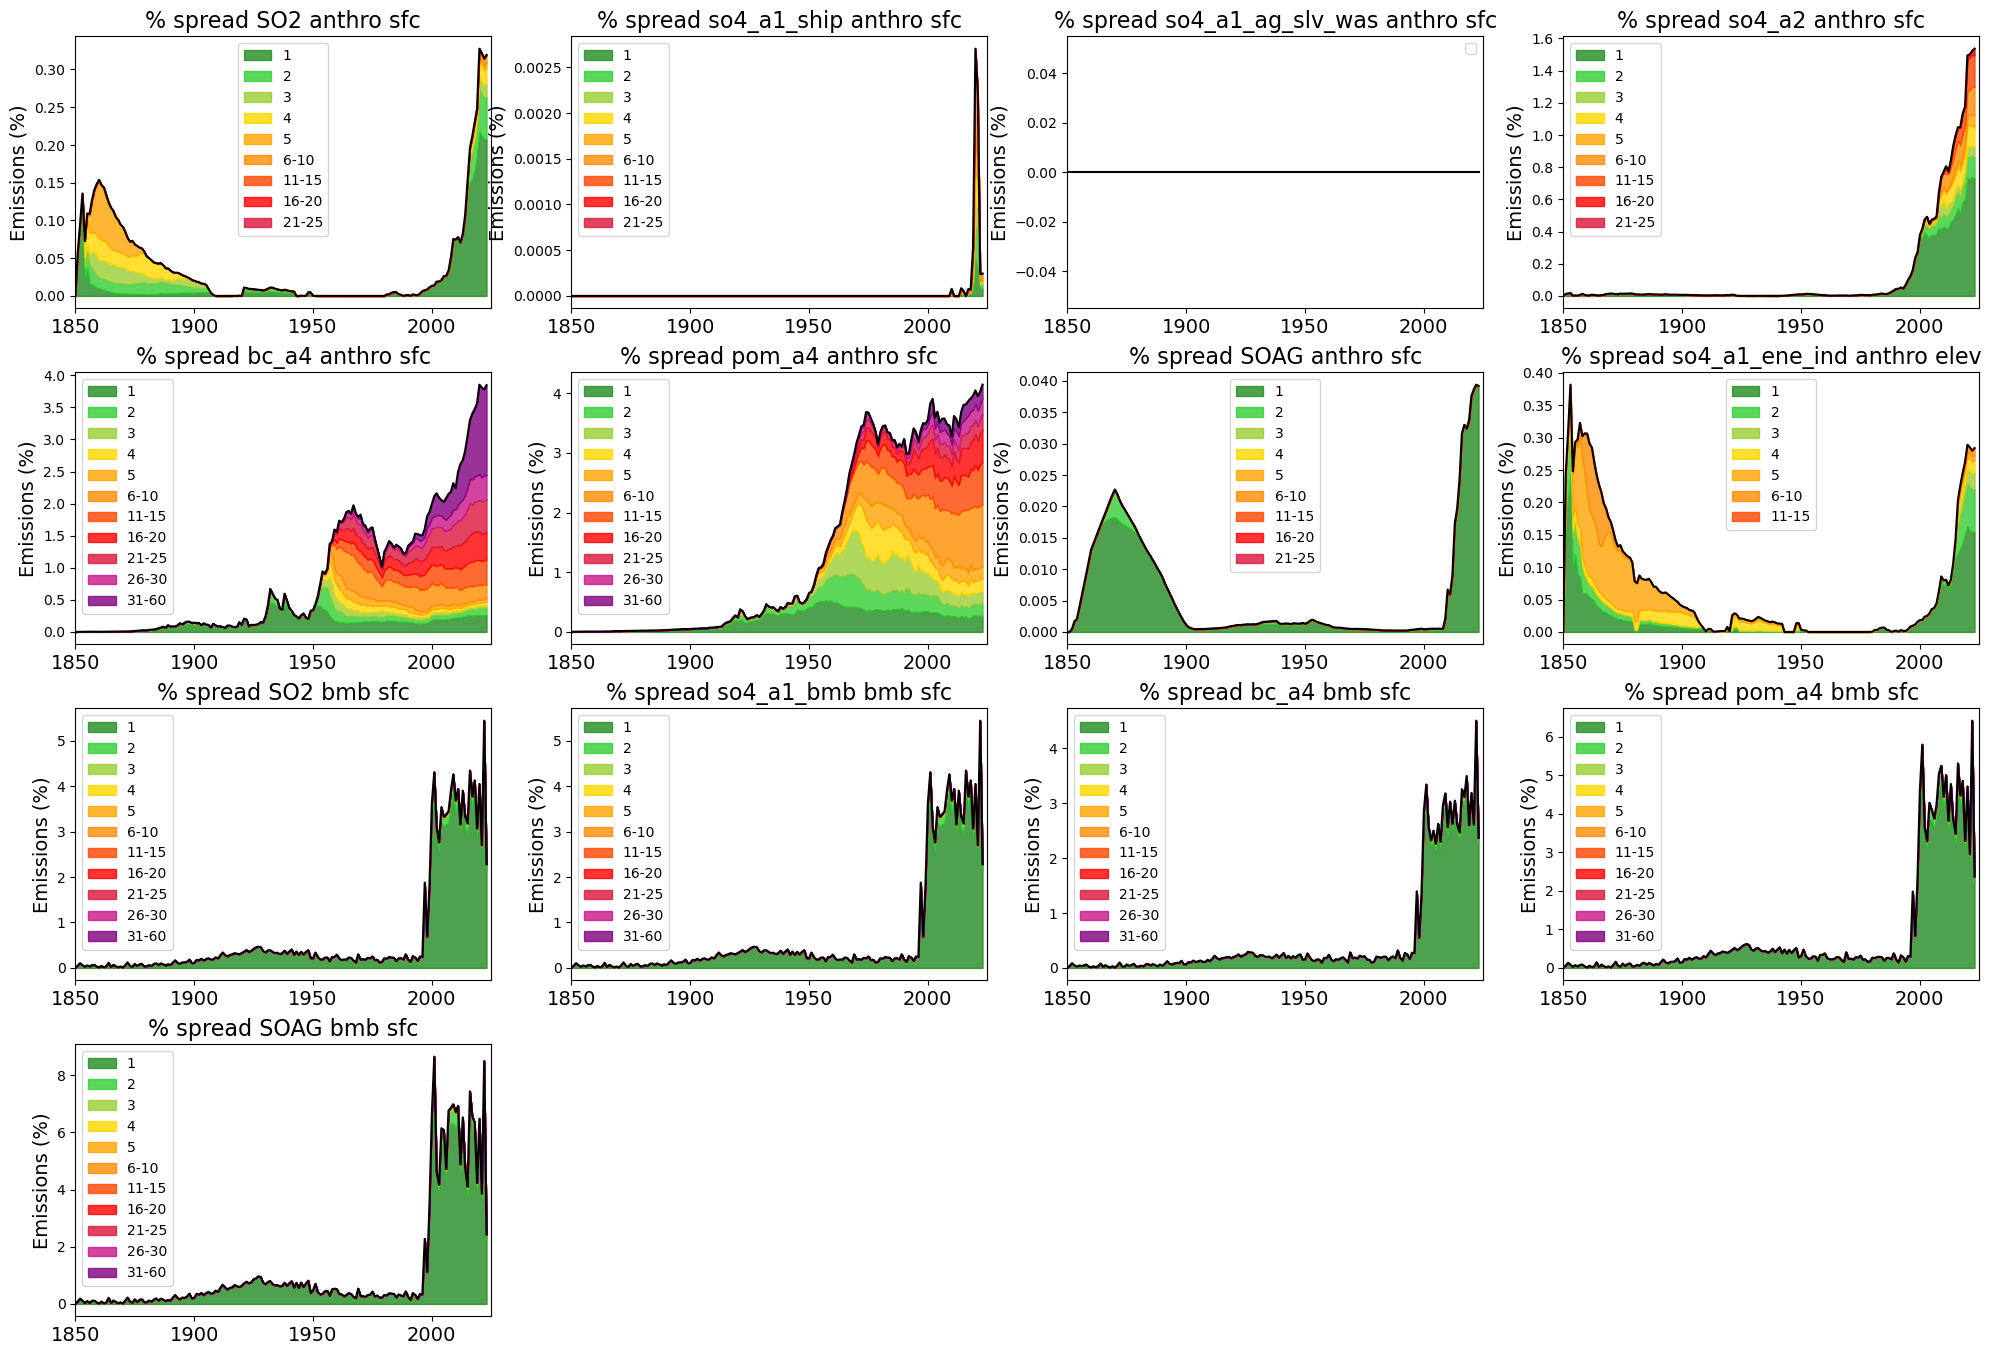

In [22]:
fig = plt.figure(figsize=(16,16))

for iplot in np.arange(0,len(deficit_plot),1):
    ax = plot_the_plot(fig, deficit_plot[iplot], '% spread '+species_to_plot[iplot]+' '+forcing_type_to_plot[iplot]+' '+emiss_type_to_plot[iplot],
                       x1[iplot],x2[iplot],y1[iplot],y2[iplot])

fig.savefig('spread.png', bbox_inches='tight', facecolor='white')

In [23]:
cluster.close()

/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/dask_jobqueue/pbs.py:82: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
